## 3D Point Cloud Visualization from Depth Image (Matplotlib)

This notebook demonstrates how to convert a depth image into a 3D point cloud using the core logic from `adapt3r_policy.py`. It uses `matplotlib` for 3D visualization and features a depth map of a sphere for clear debugging.

### 1. Setup and Imports

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import einops
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### 2. Replicating Core Logic from `adapt3r_policy.py`

In [7]:
class PointCloudUtils:
    @staticmethod
    def depth2fgpcd_batch(depth, cam_params):
        B, ncam, h, w = depth.shape
        fx = cam_params[..., 0, 0].view(B, ncam, 1, 1)
        fy = cam_params[..., 1, 1].view(B, ncam, 1, 1)
        cx = cam_params[..., 0, 2].view(B, ncam, 1, 1)
        cy = cam_params[..., 1, 2].view(B, ncam, 1, 1)
        pos_y, pos_x = torch.meshgrid(torch.arange(h, device=depth.device, dtype=torch.float32), torch.arange(w, device=depth.device, dtype=torch.float32), indexing='ij')
        pos_x = pos_x.expand(B, ncam, -1, -1)
        pos_y = pos_y.expand(B, ncam, -1, -1)
        x_coords = (pos_x - cx) * depth / fx
        y_coords = (pos_y - cy) * depth / fy
        pcd_cam = torch.stack([x_coords, y_coords, depth], dim=-1)
        return einops.rearrange(pcd_cam, 'b ncam h w c -> b ncam (h w) c')

    @staticmethod
    def batch_transform_point_cloud(pcd, transform):
        pcd_homo = F.pad(pcd, (0, 1), mode="constant", value=1.0)
        transform = transform.to(dtype=pcd.dtype)
        trans_pcd_homo = torch.einsum('bn...d,bn...id->bn...i', pcd_homo, transform)
        return trans_pcd_homo[..., :-1]

    @staticmethod
    def lift_point_cloud_batch(depths, intrinsics, extrinsics):
        pcd_cam = PointCloudUtils.depth2fgpcd_batch(depths, intrinsics)
        trans_pcd = PointCloudUtils.batch_transform_point_cloud(pcd_cam, extrinsics)
        return trans_pcd

### 3. Generating a Sphere Depth Map

To provide a more visually distinct example, we create a depth map of a sphere. The background will have a constant depth, while the sphere will appear closer to the camera.

In [8]:
# --- Simulation Parameters ---
H, W = 128, 128
B, NCAM = 1, 1
radius = H / 4
center_x, center_y = W / 2, H / 2
sphere_depth = 2.0
background_depth = 5.0

# --- Create Sphere Depth Image ---
x, y = np.ogrid[:H, :W]
dist_from_center = np.sqrt((x - center_y)**2 + (y - center_x)**2)
depth_numpy = np.full((H, W), background_depth, dtype=np.float32)
sphere_mask = dist_from_center <= radius
# Calculate z-coordinate for the sphere surface
z = np.sqrt(radius**2 - dist_from_center[sphere_mask]**2)
depth_numpy[sphere_mask] = sphere_depth + (radius - z)

depth_tensor = torch.from_numpy(depth_numpy).float().view(B, NCAM, H, W)

# --- Camera Intrinsics & Extrinsics ---
fx, fy = 64, 64
cx, cy = W / 2, H / 2
intrinsics = torch.eye(3).repeat(B, NCAM, 1, 1)
intrinsics[:, :, 0, 0] = fx
intrinsics[:, :, 1, 1] = fy
intrinsics[:, :, 0, 2] = cx
intrinsics[:, :, 1, 2] = cy
extrinsics = torch.eye(4).repeat(B, NCAM, 1, 1)

### 4. Visualize the Input Depth Image

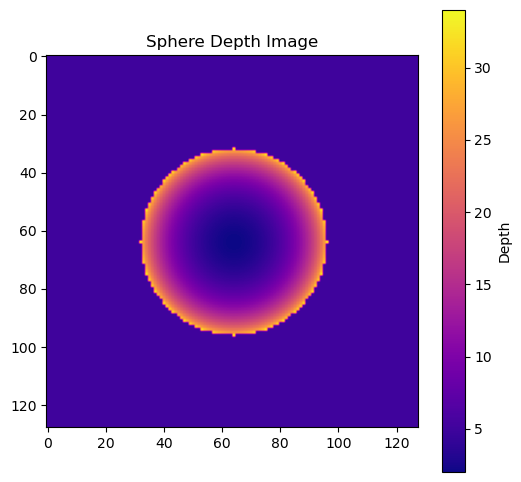

In [9]:
plt.figure(figsize=(6, 6))
plt.imshow(depth_numpy, cmap='plasma')
plt.title('Sphere Depth Image')
plt.colorbar(label='Depth')
plt.show()

### 5. Generate and Visualize the Point Cloud

In [10]:
point_cloud = PointCloudUtils.lift_point_cloud_batch(depth_tensor, intrinsics, extrinsics)
pcd_numpy = point_cloud.squeeze().detach().numpy()

# --- Interactive 3D Visualization using Plotly ---
num_points_to_viz = 4096
if pcd_numpy.shape[0] > num_points_to_viz:
    sample_indices = np.random.choice(pcd_numpy.shape[0], num_points_to_viz, replace=False)
    pcd_sample = pcd_numpy[sample_indices]
else:
    pcd_sample = pcd_numpy

fig = go.Figure(data=[
    go.Scatter3d(
        x=pcd_sample[:, 0],
        y=pcd_sample[:, 1],
        z=pcd_sample[:, 2],
        mode='markers',
        marker=dict(
            size=2,
            color=pcd_sample[:, 2],
            colorscale='Plasma',
            opacity=0.8
        )
    )
])

# Update layout for correct aspect ratio and titles
fig.update_layout(
    title='Interactive 3D Point Cloud of a Sphere',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectratio=dict(x=1, y=1, z=1)
    ),
    margin=dict(r=0, b=0, l=0, t=40)
)

fig.show()

NameError: name 'go' is not defined